# **Demo Computer Vision**

Demostramos de forma práctica cómo se aplican modelos de visión por computador para:
1. **Explorar** un dataset de tracking de pelota de tenis (TrackNet)
2. **Detectar** jugadores usando YOLO pre-entrenado
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Verificar si hay GPU disponible
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
else:
    print("Se usará CPU (suficiente para inferencia)")

PyTorch version: 2.10.0+cpu
CUDA disponible: False
Se usará CPU (suficiente para inferencia)


---
## 1. Exploración del Dataset de Tennis (TrackNet)

El dataset contiene frames etiquetados de partidos de tenis con la posición de la pelota.

**Columnas del CSV:**
- `file name`: nombre del frame (imagen .jpg)
- `visibility`: 0=no visible, 1=visible, 2=parcialmente visible, 3=ocluida
- `x-coordinate`, `y-coordinate`: posición de la pelota en píxeles
- `status`: 0=en vuelo, 1=golpe (hit), 2=bote (bounce)

In [2]:
# Ruta base del dataset
DATASET_PATH = Path("Dataset")  # Ruta relativa desde el notebook

# Cargo un CSV de ejemplo
sample_csv = DATASET_PATH / "game1" / "Clip1" / "Label.csv"
df = pd.read_csv(sample_csv)

print(f"Shape: {df.shape}")
print(f"\nPrimeras filas:")
df.head(10)

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/game1/Clip1/Label.csv'

In [ ]:
# Estadísticas del dataset
print("-" * 50)
print("ESTADÍSTICAS DEL CLIP")
print("-" * 50)
print(f"Total de frames: {len(df)}")
print(f"\nDistribución de visibilidad:")
visibility_map = {0: 'No visible', 1: 'Visible', 2: 'Parcialmente visible', 3: 'Ocluida'}
for val, count in df['visibility'].value_counts().sort_index().items():
    print(f"  {visibility_map.get(val, val)}: {count} frames ({count/len(df)*100:.1f}%)")

print(f"\nDistribución de status:")
status_map = {0: 'En vuelo', 1: 'Golpe (hit)', 2: 'Bote (bounce)'}
# Solo frames donde la pelota es visible
df_visible = df[df['visibility'] > 0].copy()
for val, count in df_visible['status'].value_counts().sort_index().items():
    print(f"  {status_map.get(val, val)}: {count} frames")

print(f"\nRango de coordenadas (solo frames visibles):")
print(f"  X: [{df_visible['x-coordinate'].min()}, {df_visible['x-coordinate'].max()}]")
print(f"  Y: [{df_visible['y-coordinate'].min()}, {df_visible['y-coordinate'].max()}]")

In [ ]:
# Todos los clips del dataset
all_csvs = sorted(glob.glob(str(DATASET_PATH / "game*" / "Clip*" / "Label.csv")))
print(f"Total de clips encontrados: {len(all_csvs)}")

# Resumen por juego
summary = []
for csv_path in all_csvs:
    parts = Path(csv_path).parts
    game = [p for p in parts if 'game' in p][0]
    clip = [p for p in parts if 'Clip' in p][0]
    temp_df = pd.read_csv(csv_path)
    summary.append({
        'game': game,
        'clip': clip,
        'total_frames': len(temp_df),
        'visible_frames': (temp_df['visibility'] > 0).sum(),
        'hits': (temp_df['status'] == 1).sum() if 'status' in temp_df.columns else 0,
        'bounces': (temp_df['status'] == 2).sum() if 'status' in temp_df.columns else 0
    })

df_summary = pd.DataFrame(summary)
print(f"\nResumen por juego:")
print(df_summary.groupby('game').agg({
    'clip': 'count',
    'total_frames': 'sum',
    'visible_frames': 'sum',
    'hits': 'sum',
    'bounces': 'sum'
}).rename(columns={'clip': 'num_clips'}))

print(f"\nTotal general:")
print(f"  Juegos: {df_summary['game'].nunique()}")
print(f"  Clips: {len(df_summary)}")
print(f"  Frames: {df_summary['total_frames'].sum():,}")

In [ ]:
# Visualización: Trayectoria de la pelota en un clip
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Trayectoria completa
ax = axes[0]
visible = df[df['visibility'] > 0]
scatter = ax.scatter(visible['x-coordinate'], visible['y-coordinate'],
                     c=range(len(visible)), cmap='viridis', s=15, alpha=0.7)
ax.set_xlabel('X (píxeles)')
ax.set_ylabel('Y (píxeles)')
ax.set_title('Trayectoria de la pelota (Game1/Clip1)')
ax.invert_yaxis()  # En imágenes, Y crece hacia abajo
plt.colorbar(scatter, ax=ax, label='Frame #')

# 2. Trayectoria coloreada por status
ax = axes[1]
colors = {0: 'blue', 1: 'red', 2: 'green'}
labels = {0: 'En vuelo', 1: 'Golpe', 2: 'Bote'}
for status_val, group in visible.groupby('status'):
    ax.scatter(group['x-coordinate'], group['y-coordinate'],
               c=colors.get(status_val, 'gray'), label=labels.get(status_val, '?'),
               s=30, alpha=0.7)
ax.set_xlabel('X (píxeles)')
ax.set_ylabel('Y (píxeles)')
ax.set_title('Eventos: Golpes y Botes')
ax.invert_yaxis()
ax.legend()

# 3. Posición Y en el tiempo (ver parábolas)
ax = axes[2]
frame_nums = [int(f.replace('.jpg', '')) for f in visible['file name']]
ax.plot(frame_nums, visible['y-coordinate'], 'b-', alpha=0.5, linewidth=1)
ax.scatter(frame_nums, visible['y-coordinate'], c='blue', s=10)
# Marcar hits y bounces
hits = visible[visible['status'] == 1]
bounces = visible[visible['status'] == 2]
hit_frames = [int(f.replace('.jpg', '')) for f in hits['file name']]
bounce_frames = [int(f.replace('.jpg', '')) for f in bounces['file name']]
ax.scatter(hit_frames, hits['y-coordinate'], c='red', s=80, marker='v', label='Golpe', zorder=5)
ax.scatter(bounce_frames, bounces['y-coordinate'], c='green', s=80, marker='^', label='Bote', zorder=5)
ax.set_xlabel('Frame')
ax.set_ylabel('Y (píxeles)')
ax.set_title('Posición Y en el tiempo (parábolas)')
ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.show()

---
## 3. Detección de Jugadores con YOLO (Pre-entrenado)

Usamos **YOLOv8** pre-entrenado en COCO (80 clases, incluye "person").
El modelo ya sabe detectar personas.

Se podría tratar de entrenar nuestro propio modelo en Colab por ejemplo.

### ¿Qué es YOLO?
- **Y**ou **O**nly **L**ook **O**nce: detecta objetos en una sola pasada
- Tiempo real: ~30+ FPS en GPU, ~5 FPS en CPU
- Familia: v5, v8, v9, v10, v11... (ultralytics mantiene v8/v11)

In [ ]:
from ultralytics import YOLO

# Cargar modelo pre-entrenado (se descarga automáticamente ~6MB para nano)
# Variantes: yolov8n (nano, rápido), yolov8s (small), yolov8m (medium), yolov8l (large), yolov8x (extra large)
model = YOLO('yolov8n.pt')  # nano: ideal para demo, rápido incluso en CPU

print(f"Modelo cargado: YOLOv8 Nano")
print(f"Clases que detecta: {len(model.names)}")
print(f"Algunas clases: {dict(list(model.names.items())[:10])}")
print(f"\nClase 'person' = ID {[k for k,v in model.names.items() if v=='person'][0]}")

In [ ]:
frame_path = DATASET_PATH / "game1" / "Clip1" / "0000.jpg"
if frame_path.exists():
    results = model(str(frame_path))
    results[0].show()  # Muestra la imagen con las detecciones

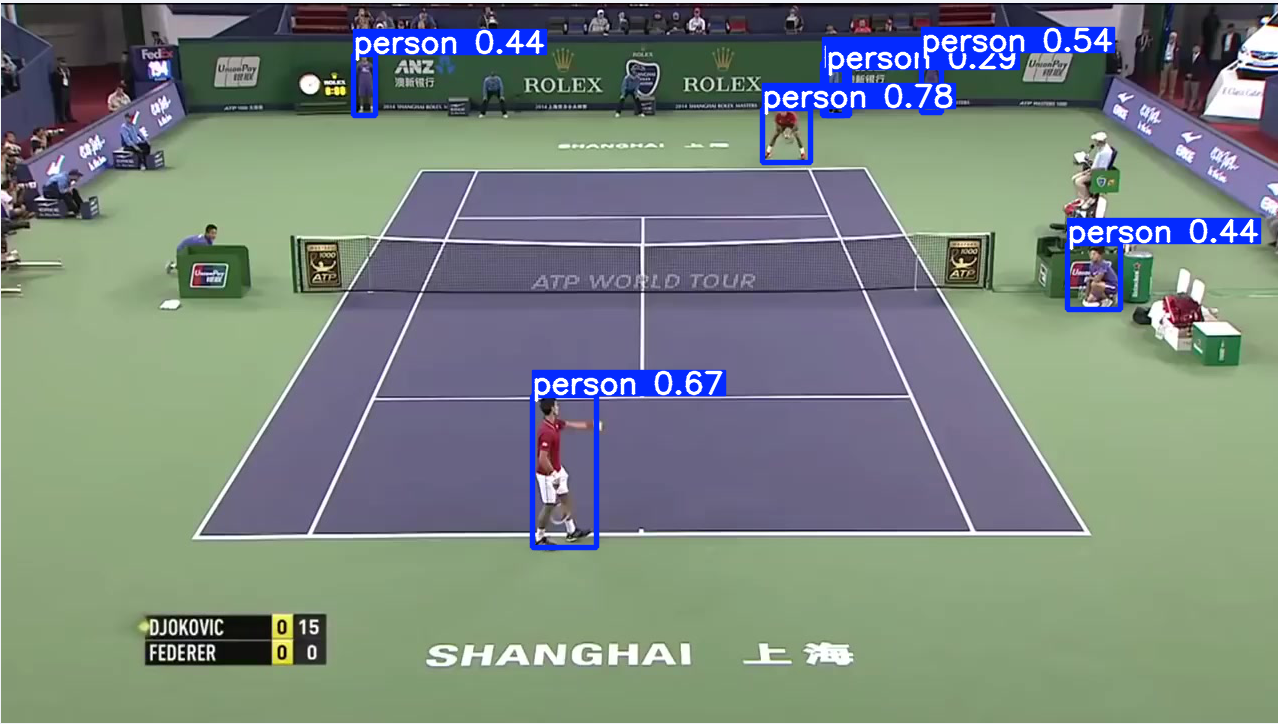